# Hydrodynamic length

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math, scipy, skimage, os
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,

    'svg.fonttype':'none',
    'pdf.fonttype': 42,

    'axes.linewidth': 0.5,

    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,

    'xtick.major.size': 2,
    'ytick.major.size': 2,
    'xtick.major.pad': 1,
    'ytick.major.pad': 1,

    'axes.labelpad': 1
})

In [2]:
# pivlab rearrangement and divergence calculation

def piv_lab_rearrange(folder, pixel_size, t_interval, every = None):
        
    data_files = []

    for i in os.listdir(folder):
        if '.txt' in i and 'PIVlab' in i:
            data_files.append(i)
    
    frame_num = len(data_files)
    
    x2 = [[]]*frame_num
    y2 = [[]]*frame_num
    u2 = [[]]*frame_num
    v2 = [[]]*frame_num
    
    with open(folder + '/PIVlab_0001.txt') as f:
        first_line = f.readline()
    if first_line[:6] == "x [px]":
        header = 0
    else:
        header = 2

    for frame in range(1,frame_num+1):
        
        if frame < 10:
            frame_name = '000' + str(frame)
        elif frame >=10 and frame < 100:
            frame_name = '00' + str(frame)
        elif frame >= 100:
            frame_name = '0' + str(frame)
            
        data = pd.read_csv(folder + '/PIVlab_'+ frame_name + '.txt',
                            sep=",", header=header)#.fillna(0)
        x2[frame-1] = np.array(data['x [px]'])
        y2[frame-1] = np.array(data['y [px]'])
        u2[frame-1] = np.array(data['u [px/frame]'])
        v2[frame-1] = np.array(data['v [px/frame]'])
        # u2[frame-1][np.isnan(u2[frame-1])] = 0
        # v2[frame-1][np.isnan(v2[frame-1])] = 0
        
    x2 = np.array(x2)
    y2 = np.array(y2)
    u2 = np.array(u2) * pixel_size / t_interval 
    v2 = np.array(v2) * pixel_size / t_interval 
    
    # x3y3 shape: x*y    
    x3 = np.unique(x2)
    y3 = np.unique(y2)    
    
    # xy shape: x, y
    # uv shape: t, x, y
    # vel shape: t, x, y
    x = x2[0].reshape(len(x3), len(y3))
    y = y2[0].reshape(len(x3), len(y3))
    u = u2.reshape(frame_num, len(x3), len(y3))
    v = v2.reshape(frame_num, len(x3), len(y3))
    
    # x2y2u2v2vel2 shape: t, x*y
    u2 = np.nan_to_num(u2)
    v2 = np.nan_to_num(v2)
    
    vel = np.sqrt(v**2 + u**2)
    vel2 = np.nan_to_num(vel.reshape(frame_num, len(y3)*len(x3)))
    
    class Piv_data_rearranged:
        def __init__(self, t_interval, frame_num, x, y, u, v, vel, x2, y2, u2, v2, vel2, x3, y3):
            self.t = np.arange(frame_num-1) * t_interval
            self.f = frame_num
            self.x, self.y, self.u, self.v = x,y,u,v
            self.x2, self.y2, self.u2, self.v2 = x2,y2,u2,v2
            self.x3, self.y3 = x3, y3
            self.vel, self.vel2 = vel, vel2
        
    data = Piv_data_rearranged(t_interval, frame_num, x, y, u, v, vel, x2, y2, u2, v2, vel2, x3, y3)
#     print('shape of [ x y ]: x, y' + '\n' +
#           'shape of [ u v vel ]: t, x, y' + '\n' +
#           'shape of [ x2 y2 u2 v2 vel2 ]: t, x*y' + '\n'
#           'shape of [ x3 y3 ]: x*y')
    
    return data


def divergence(x_i, y_i, u_i, v_i):
    x = np.unique(x_i)
    y = np.unique(y_i)

    du_dx = np.gradient(u_i, x, axis=0)
    dv_dy = np.gradient(v_i, y, axis=1)

    return du_dx + dv_dy

In [3]:
# Write a function to create new folder
def create_folder(path):
    isExist = os.path.exists(path) 
    if not isExist:
        os.makedirs(path)

# Import the data info

In [4]:
data_collection = pd.read_excel('B:\\archive\\xtong\\xin home drive\\data_meroblastic\\majority_data_info.xlsx', sheet_name = 'lci', dtype={'PIV_rep': int})
data_collection = data_collection.loc[data_collection.PIV == 'done']

pixel_size = 0.34
t_interval = 0.2
data_collection

,rep,experiment,embryo_no,folder_name,cut_no,type,pre_cut,cut,post_cut,start,...,orientation,position,PIV,piv_rep,cut_position,data_export,peak_frame,first_frame_time,hydrodynamic_length_quanti1,hydrodynamic_length_quanti2
6,6,XIN211116_LaserCutter,1,13,2.0,cb,-10.0,267.0,100.0,257.0,...,NaN,very superficial,done,1.0,240.0,done,NaN,NaN,"-75,-25",NaN
11,11,XIN211116_LaserCutter,2,24,1.0,cb,-10.0,115.0,100.0,105.0,...,NaN,star_to_show,done,2.0,224.0,done,11.0,-2.0,"-70,-20","20,70"
14,14,XIN211116_LaserCutter,2,26,1.0,cb,-10.0,71.0,100.0,61.0,...,NaN,NaN,done,3.0,378.0,done,NaN,NaN,"-110, -25",NaN
22,22,XIN211117_LaserCutter,1,15,1.0,cb,-10.0,37.0,100.0,27.0,...,NaN,NaN,done,4.0,231.0,done,NaN,NaN,"-70,-10","10,70"
25,25,XIN211117_LaserCutter,3,33,1.0,cb,-10.0,61.0,80.0,51.0,...,NaN,NaN,done,5.0,232.0,done,NaN,NaN,"-75,-10","20,70"
29,29,XIN211117_LaserCutter,5,42,1.0,cb,-10.0,27.0,100.0,17.0,...,NaN,not very very superficial,done,6.0,249.0,done,NaN,NaN,"-80,-10","40,60"
35,35,XIN211118_LaserCutter,3,32,1.0,cb,-10.0,112.0,100.0,102.0,...,NaN,NaN,done,7.0,250.0,done,NaN,NaN,"20,80",NaN


# Show an individual flow field after cut

In [5]:
replicate_no =2

replicate = data_collection.loc[data_collection.piv_rep == replicate_no].iloc[0]
replicate_folder = replicate.experiment +'\\' + str(replicate.folder_name) + "_\\" + str(replicate.folder_name) + "_" + str(int(replicate.cut_no)) +"_piv"
print(replicate_folder)

pivlabtxt_folder = replicate_folder + "\\pivlabtxt"
print(pivlabtxt_folder)
Piv = piv_lab_rearrange(pivlabtxt_folder, pixel_size, t_interval)
x, y, u, v, f, vel = Piv.x, Piv.y, Piv.u, Piv.v, Piv.f, Piv.vel

XIN211116_LaserCutter\24_\24_1_piv
XIN211116_LaserCutter\24_\24_1_piv\pivlabtxt


In [6]:
movie = skimage.io.imread('XIN211116_LaserCutter\\24_\\24_1_piv\\24_1_roi.tif')
frames, ys, xs = movie.shape

In [7]:
u_unit, v_unit = u/vel, v/vel

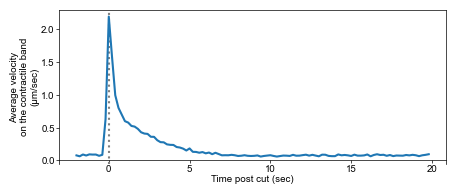

In [8]:
# calculate the velocity on the cleavage furrow
middle_u = u.shape[2]//2
u_on_cb = u[:, :, middle_u-1: middle_u+2]
u_on_cb = np.average(u_on_cb, axis=2)

speed = np.nanmean(np.abs(u_on_cb), axis=1)
peak_frame = np.argmax(speed)
# set the v axis
time = (np.arange(f) - peak_frame) * t_interval

fig, ax = plt.subplots(figsize=[5,2])
ax.axvline(x=0, color='grey', ls='dotted')
ax.plot(time, speed)
# ax.plot(peak_frame, speed[peak_frame], 'x', color='r')
ax.spines['bottom'].set_position('zero')
ax.set_ylabel('Average velocity\non the contractile band\n(\u03BCm/sec)')
ax.set_xlabel('Time post cut (sec)')
plt.show()


-70,-20
20,70


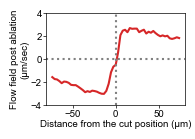

In [9]:
# set the x axis
velocity_peak_frame = u_on_cb[peak_frame]
x_position = np.unique(x) *  pixel_size

# find the cut position
cut_position = replicate.cut_position * pixel_size
from xint_toolbox import find_closest
cut_position = find_closest(x_position, cut_position)[1]
cut_position = x_position[cut_position]
x_position -= cut_position

# plot the velocity_peak_frame

fig,ax=plt.subplots(figsize=[1.8, 1.2])
ax.plot(x_position, velocity_peak_frame, color='tab:red')
ax.axhline(y=0, color='grey', ls='dotted')
ax.axvline(x=0, color='grey', ls='dotted')
# velocity_peak_frame_gaussian = scipy.ndimage.gaussian_filter(velocity_peak_frame, sigma=1)
# ax.plot(x_position, velocity_peak_frame_gaussian)

hls = []
for hyle in [replicate.hydrodynamic_length_quanti1, replicate.hydrodynamic_length_quanti2]:
    if type(hyle)==str:
        print(hyle)
        comma = hyle.index(',')
        a,b = int(hyle[:comma]), int(hyle[comma+1:])
        # ax.plot(x_position[(a<x_position) & (x_position<b)], velocity_peak_frame_gaussian[(a<x_position) & (x_position<b)])
        # resa, resb = x_position[(a<x_position) & (x_position<b)], velocity_peak_frame_gaussian[(a<x_position) & (x_position<b)]
        # res = scipy.stats.linregress(resa, resb)
        # slope, intercept = res.slope, res.intercept
        # ax.plot(resa, resa*slope+intercept)
        # hl = np.abs(-intercept/slope)
        # hl = np.abs(slope)
        # print(hl)
        # hls.append(hl)

ax.set_xlabel('Distance from the cut position (\u03BCm)')
ax.set_ylabel('Flow field post ablation\n(\u03BCm/sec)')
ax.set_ylim(-4, 4)
# plt.savefig('H:\\Xin home drive\\data_meroblastic\\Laser_cutter\\laser_cutter_i\\XIN211116_LaserCutter\\24_\\24_1_piv\\24_1_roi_hydrodynamic_length_plot_toshow.svg')

plt.show()

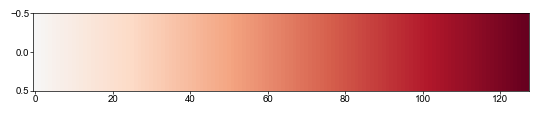

In [10]:
# new cmap
new_reds_cmap = mpl.colors.ListedColormap(mpl.colormaps['RdBu'](np.linspace(0.5,0,1024)))
plt.imshow([np.arange(128)], aspect=20, cmap=new_reds_cmap)
plt.show()

In [11]:
piv_x_step = x[1, 0] - x[0,0]

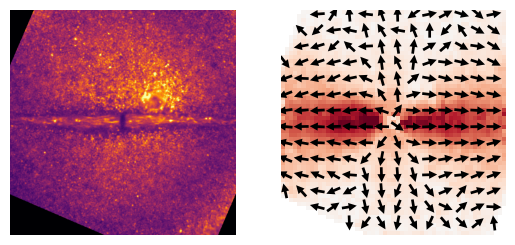

In [12]:
fig, axs = plt.subplots(1,2)
axs[0].imshow(movie[peak_frame+1], cmap='inferno', vmin=16, vmax=160)

orientation_cmap = new_reds_cmap #plt.colormaps["Greys"]
orientation_colors = vel[peak_frame]/3
stride = 4

axs[1].imshow(vel[peak_frame].T, extent=[x[0,0] - piv_x_step, x[-1,-1] + piv_x_step, x[-1,-1] + piv_x_step, x[0,0] - piv_x_step],
              cmap=new_reds_cmap, vmin=0, vmax=3, interpolation='none')
axs[1].quiver(x[::stride, ::stride].flatten(), y[::stride, ::stride].flatten(),
              u_unit[peak_frame][::stride, ::stride].flatten(), v_unit[peak_frame][::stride, ::stride].flatten(),
              scale = 15,# color=orientation_cmap(orientation_colors[::stride, ::stride].flatten()),
              width = 0.012, pivot = 'mid', headwidth =3, headlength = 3, headaxislength = 3)

axs[0].set_axis_off()
axs[1].set_axis_off()
axs[1].set_aspect('equal')
axs[1].set_xlim(0, xs)
axs[1].set_ylim(ys, 0)

plt.savefig('hydrodynamic_length_individual_toshow.svg')
plt.show()

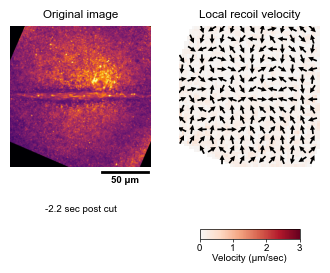

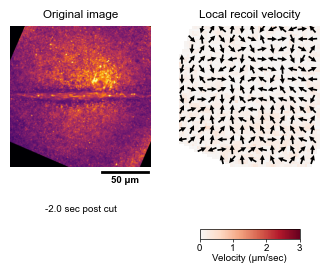

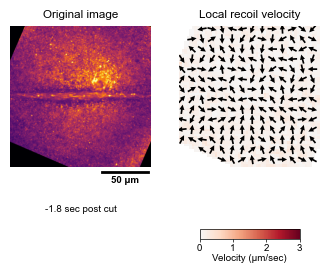

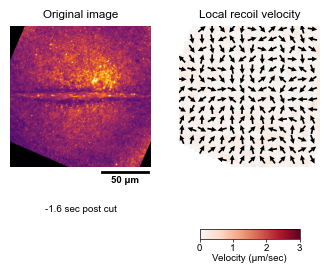

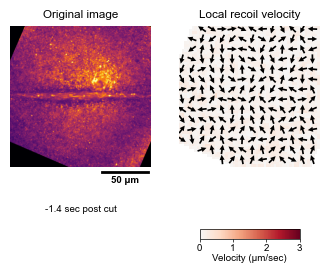

In [13]:
folder_name = "hydrodynamic_length_individual_toshow"
create_folder(folder_name)

from mpl_toolkits.axes_grid1 import make_axes_locatable

j=0
for frame in range(81):
# for frame in [frames]:
    j += 1
    fig, axs = plt.subplots(2,2, figsize=[4,3], gridspec_kw={"height_ratios": [1,0.03]})

    axs[0, 0].imshow(movie[frame+1], cmap='inferno', vmin=16, vmax=160)

    orientation_cmap = new_reds_cmap #plt.colormaps["Greys"]
    orientation_colors = vel[frame]/3
    stride = 4
    # axs[0,1].quiver(x[::stride, ::stride].flatten(), y[::stride, ::stride].flatten(),
    #             u[frame][::stride, ::stride].flatten(), v[frame][::stride, ::stride].flatten(),
    #             scale = 45, color=orientation_cmap(orientation_colors[::stride, ::stride].flatten()),
    #             width = 0.012, pivot = 'mid', headwidth =3, headlength = 3, headaxislength = 3)
    
    axs[0,1].imshow(vel[frame].T, extent=[x[0,0] - piv_x_step, x[-1,-1] + piv_x_step, x[-1,-1] + piv_x_step, x[0,0] - piv_x_step],
              cmap=new_reds_cmap, vmin=0, vmax=3, interpolation='none')
    axs[0,1].quiver(x[::stride, ::stride].flatten(), y[::stride, ::stride].flatten(),
                u_unit[frame][::stride, ::stride].flatten(), v_unit[frame][::stride, ::stride].flatten(),
                scale = 15,# color=orientation_cmap(orientation_colors[::stride, ::stride].flatten()),
                width = 0.012, pivot = 'mid', headwidth =3, headlength = 3, headaxislength = 3)

    axs[0,0].set_axis_off()
    axs[1,0].set_axis_off()

    cax1 = make_axes_locatable(axs[1,1]).append_axes('bottom', size=0.1, pad=0.1, box_aspect=1/10)
    cb1 = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=3), cmap=new_reds_cmap), 
                       cax=cax1, orientation='horizontal', label='Velocity (\u03BCm/sec)')

    axs[0,1].set_xlim(0,xs)
    axs[0,1].set_ylim(ys+88,0)
    axs[0,0].set_xlim(0,xs)
    axs[0,0].set_ylim(ys+88,0)

    axs[0,1].set_axis_off()
    axs[1,1].set_axis_off()
    axs[0,1].set_aspect('equal')

    axs[0,0].set_title('Original image')
    axs[0,1].set_title('Local recoil velocity')

    axs[1,0].text(0.5, 5, str(round((frame-11)*0.2, 1)) +' sec post cut', color='black', fontsize=7, va='center', ha='center')

    axs[0,0].plot([xs-(50/0.34)-10, xs-10], [ys+15, ys+15], color='black', lw=2)
    axs[0,0].text(xs-(20/0.34)-67, ys+50, "50 \u03BCm", color='black', fontweight='bold', fontsize=7)

    if frame>=8 and frame<11:
        axs[1,0].text(0.5, 0, 'During the cut', va='center', ha='center',
                      color='tab:red', fontsize=10, fontweight='bold', bbox=dict(facecolor='none', edgecolor='tab:red', boxstyle='square,pad=0.3'))
    elif frame>=11:
        axs[1,0].text(0.5, 0, 'After the cut', va='center', ha='center',
                      color='grey', fontsize=10, fontweight='bold', bbox=dict(facecolor='none', edgecolor='grey', boxstyle='square,pad=0.3'))


    plt.savefig(folder_name + '/f' + str(frame) + '.png', dpi=500, bbox_inches = 'tight', pad_inches = 0.1)
    if j<=5:
        plt.show()
    else:
        plt.close()

# Plotting many replicates

In [14]:
from xint_toolbox import find_closest

x_positions = []
velocity_peak_frames = []

for replicate_no in range(1,8):
    print(replicate_no)
    replicate = data_collection.loc[data_collection.piv_rep == replicate_no].iloc[0]
    replicate_folder = replicate.experiment +'\\' + str(replicate.folder_name) + "_\\" + str(replicate.folder_name) + "_" + str(int(replicate.cut_no)) +"_piv"
    print(replicate_folder)

    pivlabtxt_folder = replicate_folder + "\\pivlabtxt"
    print(pivlabtxt_folder)
    Piv = piv_lab_rearrange(pivlabtxt_folder, pixel_size, t_interval)
    x, y, u, v, f = Piv.x, Piv.y, Piv.u, Piv.v, Piv.f

    # calculate the velocity on the cleavage furrow
    middle_u = u.shape[2]//2
    u_on_cb = u[:, :, middle_u-1: middle_u+2]
    u_on_cb = np.average(u_on_cb, axis=2)

    speed = np.nanmean(np.abs(u_on_cb), axis=1)
    peak_frame = np.argmax(speed)
    # set the v axis
    time = (np.arange(f) - peak_frame) * t_interval

    # set the x axis
    velocity_peak_frame = u_on_cb[peak_frame]
    x_position = np.unique(x) *  pixel_size

    # find the cut position
    cut_position = replicate.cut_position * pixel_size
    cut_position = find_closest(x_position, cut_position)[1]
    cut_position = x_position[cut_position]
    x_position -= cut_position

    x_positions.append(x_position)
    velocity_peak_frames.append(velocity_peak_frame)


1
XIN211116_LaserCutter\13_\13_2_piv
XIN211116_LaserCutter\13_\13_2_piv\pivlabtxt
2
XIN211116_LaserCutter\24_\24_1_piv
XIN211116_LaserCutter\24_\24_1_piv\pivlabtxt
3
XIN211116_LaserCutter\26_\26_1_piv
XIN211116_LaserCutter\26_\26_1_piv\pivlabtxt
4
XIN211117_LaserCutter\15_\15_1_piv
XIN211117_LaserCutter\15_\15_1_piv\pivlabtxt
5
XIN211117_LaserCutter\33_\33_1_piv
XIN211117_LaserCutter\33_\33_1_piv\pivlabtxt
6
XIN211117_LaserCutter\42_\42_1_piv
XIN211117_LaserCutter\42_\42_1_piv\pivlabtxt
7
XIN211118_LaserCutter\32_\32_1_piv
XIN211118_LaserCutter\32_\32_1_piv\pivlabtxt


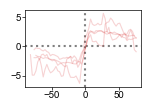

In [15]:
fig,ax=plt.subplots(figsize=[1.5, 1])

ax.axhline(y=0, color='grey', ls='dotted')
ax.axvline(x=0, color='grey', ls='dotted')

to_be_averaged_rep = np.array([2,4,5,6])-1
for i in to_be_averaged_rep:
    lw, alpha = 0.8,  0.2
    ax.plot(x_positions[i], velocity_peak_frames[i], color='tab:red', lw=lw, alpha=alpha)
plt.show()

## Fit to model, Calculate the hydrodynamic length

## Analytical velocity profile after laser ablation

### Setup

Force balance + constitutive equation give an elliptic PDE for $v$:

$$\eta\,\partial_{xx}v - \gamma\,v = -\zeta\,\partial_x\rho$$

Immediately after the cut, $\partial_x\rho$ reduces to two delta functions:

$$\partial_x\rho = -\rho_0\,\delta\!\left(x + \tfrac{w}{2}\right) + \rho_0\,\delta\!\left(x - \tfrac{w}{2}\right)$$

### Green's function

$$G(x,x') = -\frac{1}{2\eta\lambda}\,e^{-\lambda|x-x'|}, \qquad \lambda \equiv \sqrt{\frac{\gamma}{\eta}} = \frac{1}{\ell}$$

where $\ell = \sqrt{\eta/\gamma}$ is the **hydrodynamic screening length**.

### Velocity field

$$\boxed{v(x) = \frac{\zeta\rho_0}{2\eta\lambda}\left[e^{-\lambda\left|x-\frac{w}{2}\right|} - e^{-\lambda\left|x+\frac{w}{2}\right|}\right]}$$

By region (using antisymmetry $v(-x) = -v(x)$):

$$v(x) = \frac{\zeta\rho_0}{\eta\lambda}\sinh\!\left(\frac{\lambda w}{2}\right) \times \begin{cases} e^{\lambda x} & x < -w/2 \\[6pt] e^{-\lambda w/2}\,\dfrac{\sinh(\lambda x)}{\sinh(\lambda w/2)} & |x| \leq w/2 \\[8pt] e^{-\lambda x} & x > w/2 \end{cases}$$

### Recoil velocity at the cut edge

$$v_\mathrm{recoil} = \frac{\zeta\rho_0}{\eta\lambda}\,\sinh\!\!\left(\frac{\lambda w}{2}\right)e^{-\lambda w/2}$$

### Limiting regimes

| Regime | Condition | $v_\mathrm{recoil}$ |
|---|---|---|
| Narrow cut | $w \ll \ell$ | $\dfrac{\zeta\rho_0\, w}{2\eta}$ — linear in $w$ |
| Wide cut | $w \gg \ell$ | $\dfrac{\zeta\rho_0}{2\eta\lambda}$ — saturates |

$v(x) = A\left[e^{-|x - w/2|\,/\,\ell} - e^{-|x + w/2|\,/\,\ell}\right]$

In [16]:
def _estimate_p0(x, v):
    """Data-driven initial guesses for A, ell, w, x0."""
    # x0: v is antisymmetric about the cut centre → zero crossing of v
    sign_changes = np.where(np.diff(np.sign(v)))[0]
    x0 = x[sign_changes[len(sign_changes)//2]] if len(sign_changes) else x[len(x)//2]

    # A: half the peak-to-trough span
    A = (v.max() - v.min()) / 2.0

    # w: distance between the two extrema of v (≈ cut width)
    i_max, i_min = np.argmax(v), np.argmin(v)
    w = max(abs(x[i_max] - x[i_min]), (x.max() - x.min()) * 0.01)

    # ell: decay scale — distance from peak to where |v| drops to 1/e of peak
    i_peak = i_max if abs(v[i_max]) >= abs(v[i_min]) else i_min
    v_peak = abs(v[i_peak])
    tail = x > x[i_peak] if i_peak < len(x)//2 else x < x[i_peak]
    candidates = np.where(tail & (np.abs(v) < v_peak / np.e))[0]
    ell = abs(x[candidates[0]] - x[i_peak]) if len(candidates) else (x.max() - x.min()) * 0.1

    return A, ell, w, x0


def fit_hydrodynamic_length(x, v, x0_known=None, bounds=None, plot=True):
    x, v = np.asarray(x, dtype=float), np.asarray(v, dtype=float)
    mask = np.isfinite(x) & np.isfinite(v)
    x, v = x[mask], v[mask]
    if len(x) < 4:
        raise ValueError(f"Too few valid data points after masking ({len(x)}).")

    A0, ell0, w0, x0_est = _estimate_p0(x, v)
    span = x.max() - x.min()

    if x0_known is not None:
        def model(x, A, ell, w):
            lam = 1.0 / ell
            return A * (np.exp(-lam * np.abs(x - x0_known - w/2))
                      - np.exp(-lam * np.abs(x - x0_known + w/2)))
        p0 = [A0, ell0, w0]
        if bounds is None:
            bounds = ([0, 1e-6, 1e-6], [np.inf, span, span])
        param_names = ['A', 'ell', 'w']
    else:
        def model(x, A, ell, w, x0):
            lam = 1.0 / ell
            return A * (np.exp(-lam * np.abs(x - x0 - w/2))
                      - np.exp(-lam * np.abs(x - x0 + w/2)))
        p0 = [A0, ell0, w0, x0_est]
        if bounds is None:
            bounds = ([0, 1e-6, 1e-6, x.min()], [np.inf, span, span, x.max()])
        param_names = ['A', 'ell', 'w', 'x0']

    try:
        popt, pcov = scipy.optimize.curve_fit(model, x, v, p0=p0, bounds=bounds,
                               method='trf', maxfev=20000)
    except RuntimeError:
        raise RuntimeError(
            f"Fit did not converge. Initial guesses were A={A0:.3f}, "
            f"ell={ell0:.3f}, w={w0:.3f}. Try passing explicit p0 or bounds."
        )

    perr = np.sqrt(np.diag(pcov))
    result = dict(zip(param_names, popt))
    result.update({k + '_err': e for k, e in zip(param_names, perr)})
    result['popt'] = popt
    result['pcov'] = pcov
    if x0_known is not None:
        result['x0'] = x0_known
        result['x0_err'] = 0.0

    print(f"ℓ  = {result['ell']:.4f} ± {result['ell_err']:.4f}")
    print(f"w  = {result['w']:.4f}  ± {result['w_err']:.4f}")
    print(f"A  = {result['A']:.4f}  ± {result['A_err']:.4f}")
    if x0_known is None:
        print(f"x₀ = {result['x0']:.4f} ± {result['x0_err']:.4f}")

    if plot:
        x_fine = np.linspace(x.min(), x.max(), 1000)
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.scatter(x, v, s=10, color='k', alpha=0.5, label='data')
        ax.plot(x_fine, model(x_fine, *popt), color='#534AB7', lw=2,
                label=rf'fit  $\ell$ = {result["ell"]:.4f} ± {result["ell_err"]:.4f}')
        ax.axhline(0, color='gray', lw=0.5, ls='--')
        ax.set_xlabel('x')
        ax.set_ylabel('v')
        ax.legend()
        plt.tight_layout()
        plt.show()

    return result

1
XIN211116_LaserCutter\13_\13_2_piv
XIN211116_LaserCutter\13_\13_2_piv\pivlabtxt


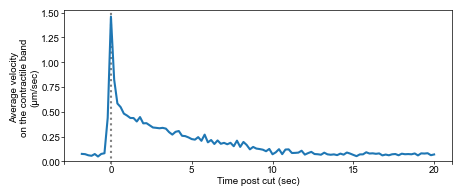

ℓ  = 130.5600 ± 47.7890
w  = 16.1552  ± 4.1656
A  = 16.2717  ± 6.8154


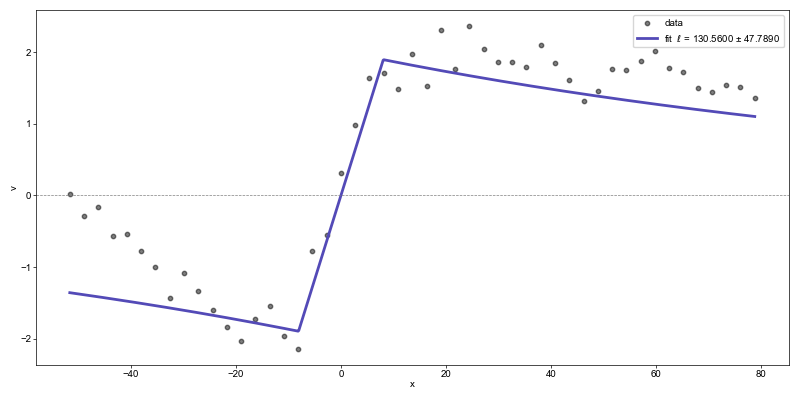

2
XIN211116_LaserCutter\24_\24_1_piv
XIN211116_LaserCutter\24_\24_1_piv\pivlabtxt


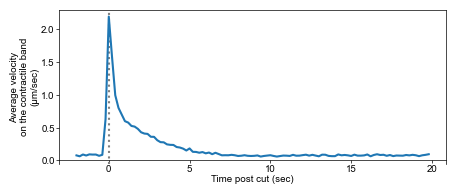

ℓ  = 120.2736 ± 10.8448
w  = 22.7994  ± 0.9304
A  = 17.2466  ± 1.5045


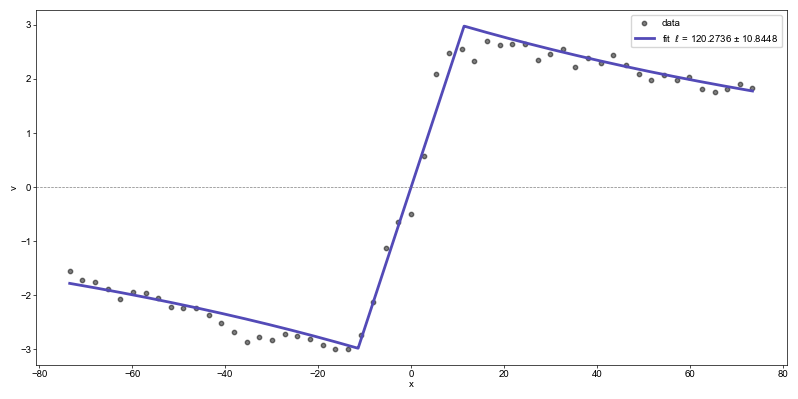

3
XIN211116_LaserCutter\26_\26_1_piv
XIN211116_LaserCutter\26_\26_1_piv\pivlabtxt


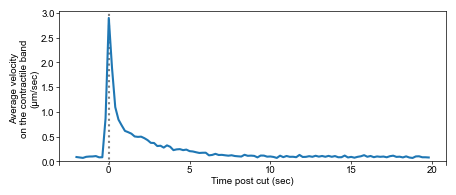

ℓ  = 136.1019 ± 18.8248
w  = 17.6657  ± 1.8264
A  = 34.1497  ± 5.4070


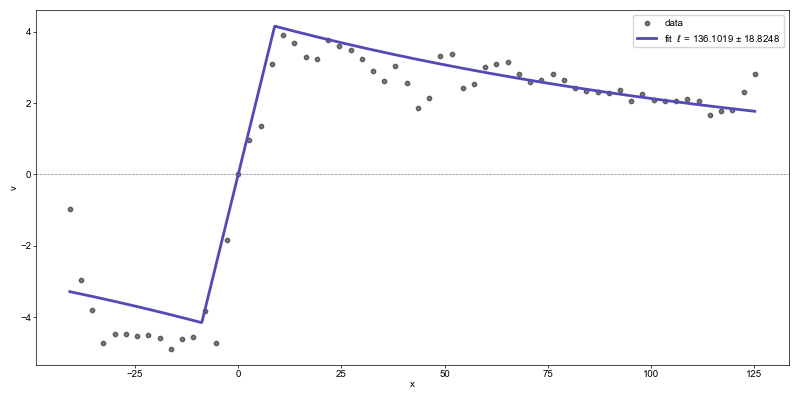

4
XIN211117_LaserCutter\15_\15_1_piv
XIN211117_LaserCutter\15_\15_1_piv\pivlabtxt


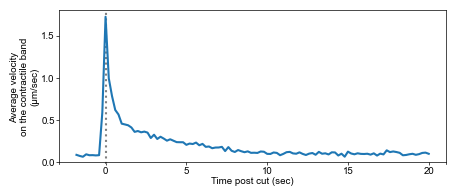

ℓ  = 70.6764 ± 8.0909
w  = 10.0974  ± 1.9088
A  = 20.9548  ± 4.4205


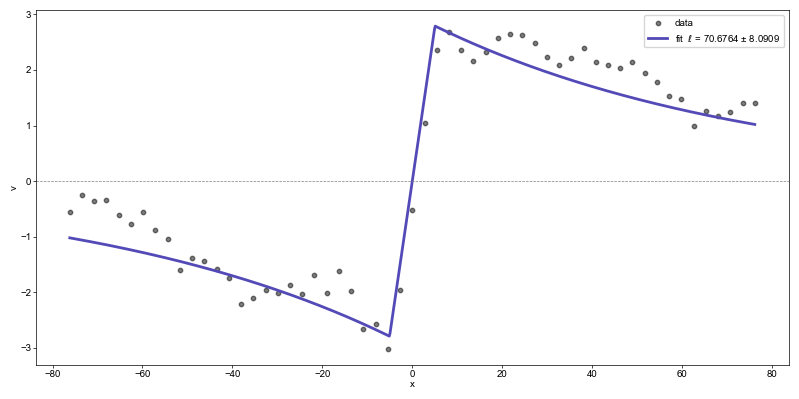

5
XIN211117_LaserCutter\33_\33_1_piv
XIN211117_LaserCutter\33_\33_1_piv\pivlabtxt


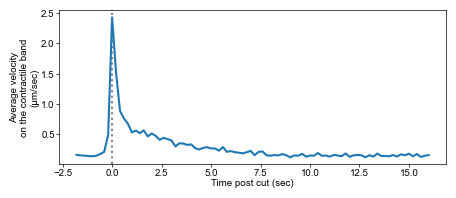

ℓ  = 66.3021 ± 12.9712
w  = 16.6216  ± 2.3998
A  = 17.4719  ± 3.5702


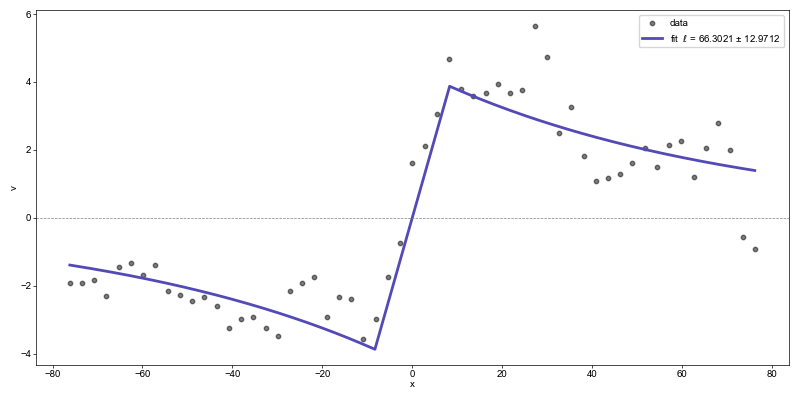

6
XIN211117_LaserCutter\42_\42_1_piv
XIN211117_LaserCutter\42_\42_1_piv\pivlabtxt


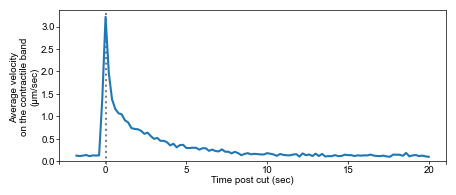

ℓ  = 157.7600 ± 84.1206
w  = 16.4681  ± 4.0369
A  = 41.3309  ± 22.5004


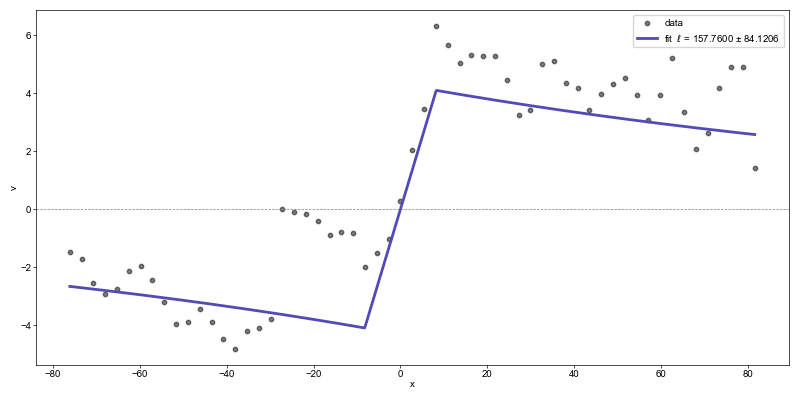

7
XIN211118_LaserCutter\32_\32_1_piv
XIN211118_LaserCutter\32_\32_1_piv\pivlabtxt


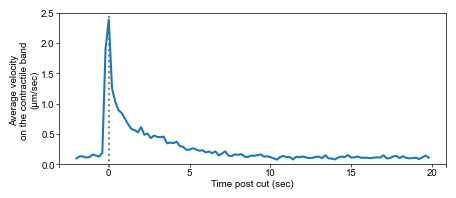

ℓ  = 127.8400 ± 42.1054
w  = 11.0800  ± 1.9544
A  = 37.2509  ± 13.0175


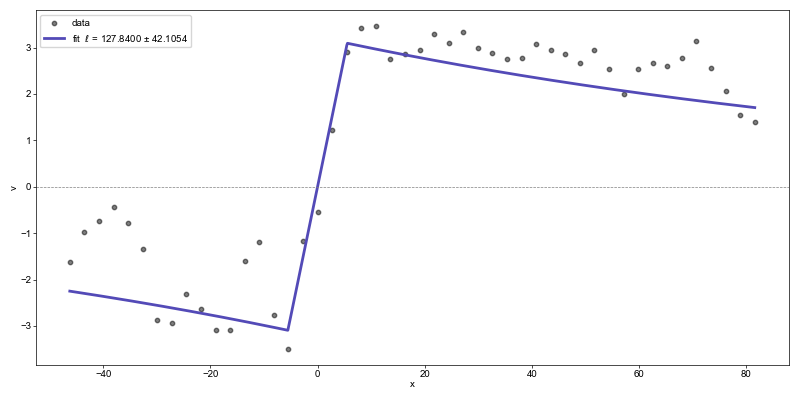

In [17]:
hydrodynamic_lengths = []
save_folder = 'hydrodynamic_length'
create_folder(save_folder)

x_positions = []
velocity_peak_frames = []


for replicate_no in range(1, len(data_collection)+1):
    print(replicate_no)
    replicate = data_collection.loc[data_collection.piv_rep == replicate_no].iloc[0]
    replicate_folder = replicate.experiment +'\\' + str(replicate.folder_name) + "_\\" + str(replicate.folder_name) + "_" + str(int(replicate.cut_no)) +"_piv"
    print(replicate_folder)

    pivlabtxt_folder = replicate_folder + "\\pivlabtxt"
    print(pivlabtxt_folder)
    Piv = piv_lab_rearrange(pivlabtxt_folder, pixel_size, t_interval)
    x, y, u, v, f = Piv.x, Piv.y, Piv.u, Piv.v, Piv.f

    # calculate the velocity on the cleavage furrow
    middle_u = u.shape[2]//2
    u_on_cb = u[:, :, middle_u-1: middle_u+2]
    u_on_cb = np.average(u_on_cb, axis=2)

    speed = np.nanmean(np.abs(u_on_cb), axis=1)
    peak_frame = np.argmax(speed)
    # set the v axis
    time = (np.arange(f) - peak_frame) * t_interval

    fig, ax = plt.subplots(figsize=[5,2])
    ax.axvline(x=0, color='grey', ls='dotted')
    ax.plot(time, speed)
    # ax.plot(peak_frame, speed[peak_frame], 'x', color='r')
    ax.spines['bottom'].set_position('zero')
    ax.set_ylabel('Average velocity\non the contractile band\n(\u03BCm/sec)')
    ax.set_xlabel('Time post cut (sec)')
    plt.show()

    # set the x axis
    velocity_peak_frame = u_on_cb[peak_frame]
    x_position = np.unique(x) *  pixel_size

    # find the cut position
    cut_position = replicate.cut_position * pixel_size
    cut_position = find_closest(x_position, cut_position)[1]
    cut_position = x_position[cut_position]
    x_position -= cut_position

    # flip the longer side to positive
    check_position = x_position[~np.isnan(velocity_peak_frame)]
    # print(check_position)
    # print(np.sum(check_position<0), np.sum(check_position>0))
    if np.sum(check_position<0) > np.sum(check_position>0):
        x_position, velocity_peak_frame = -np.flip(x_position), -np.flip(velocity_peak_frame)

    # fit the model
    a,b = x_position, velocity_peak_frame
    res = fit_hydrodynamic_length(a, b, x0_known=0.0)
    ell, ell_err = res['ell'], res['ell_err']

    hydrodynamic_lengths.append(ell)
    x_positions.append(a)
    velocity_peak_frames.append(b)

C:\Users\xtong\AppData\Local\Temp\ipykernel_10288\1094781729.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Actin\ncable'])


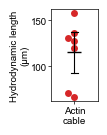

In [18]:
df = {'hydrodynamic_length_cable': np.array(hydrodynamic_lengths),
      'type': ['wt']*len(hydrodynamic_lengths)}
df = pd.DataFrame(df)

fig,ax = plt.subplots(figsize=[0.6, 1.2])
sns.swarmplot(df, x='type', y='hydrodynamic_length_cable',
              ax=ax, alpha=1, color='tab:red',
              legend=False, 
              size=5, zorder=5)
sns.pointplot(df, x='type', y='hydrodynamic_length_cable',
              color='black', ax=ax, zorder=100,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=10, markeredgewidth=1,
              capsize=0.15, err_kws={'linewidth': 0.8})
# ax.set_ylim(0, 350)
ax.set_ylabel('Hydrodynamic length\n(\u03BCm)')
ax.set_xticklabels(['Actin\ncable'])
ax.set_xlabel(None)
plt.show()

ℓ  = 134.8774 ± 35.0682
w  = 15.3857  ± 1.6106
A  = 28.2206  ± 7.2378


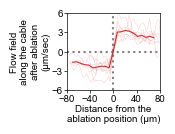

In [19]:
x_position_interp = np.linspace(-70,70,21)
velocity_peak_frame_interps = []


fig, ax = plt.subplots(figsize=[1.2, 1])
ax.axhline(y=0, color='grey', ls='dotted')
ax.axvline(x=0, color='grey', ls='dotted')

for i in range(len(x_positions)):
    a,b = x_positions[i], velocity_peak_frames[i]
    b_new = np.interp(x=x_position_interp, xp=a, fp=b, left=np.nan, right=np.nan)
    velocity_peak_frame_interps.append(b_new)
    lw, alpha = 0.4,  0.2
    ax.plot(a,b, color='tab:red', lw=lw, alpha=alpha)
    # plt.plot(x_position_interp,b_new, color='tab:red', lw=lw, alpha=alpha)
velocity_peak_frame_interps_mean = np.nanmean(velocity_peak_frame_interps, axis=0)

res = fit_hydrodynamic_length(x_position_interp, velocity_peak_frame_interps_mean, x0_known=0.0, plot=False)
x_pred = np.arange(-150, 150, 1)
v_pred = res['A'] * (np.exp((-np.abs(x_pred-res['w']/2))/res['ell']) - np.exp((-np.abs(x_pred+res['w']/2))/res['ell']))

lw=0.8
ax.plot(x_position_interp,velocity_peak_frame_interps_mean, color='tab:red', lw=lw, alpha=1)
# ax.plot(x_pred, v_pred, color='blue', ls='--', label=rf'fit  $\ell$ = {res["ell"]:.4f} ± {res["ell_err"]:.4f}', lw=lw, alpha=1)

ax.set_xlabel('Distance from the\nablation position (\u03BCm)')
ax.set_ylabel('Flow field\nalong the cable\nafter ablation\n(\u03BCm/sec)')
ax.set_xlim(-80, 80)
ax.set_ylim(-6, 6)
ax.set_xticks(np.arange(-80, 81, 40))
ax.set_yticks(np.arange(-6, 7, 3))

# ax.legend(loc='center left', bbox_to_anchor=(1.2, 0.5), frameon=True, fontsize=7)
plt.savefig('hydrodynamic_length_plot_toshow.svg')
plt.show()

ℓ  = 134.8774 ± 35.0682
w  = 15.3857  ± 1.6106
A  = 28.2206  ± 7.2378


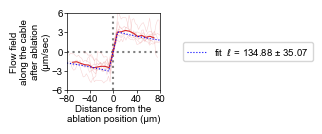

In [20]:
x_position_interp = np.linspace(-70,70,21)
velocity_peak_frame_interps = []


fig, ax = plt.subplots(figsize=[1.2, 1])
ax.axhline(y=0, color='grey', ls='dotted')
ax.axvline(x=0, color='grey', ls='dotted')

for i in range(len(x_positions)):
    a,b = x_positions[i], velocity_peak_frames[i]
    b_new = np.interp(x=x_position_interp, xp=a, fp=b, left=np.nan, right=np.nan)
    velocity_peak_frame_interps.append(b_new)
    lw, alpha = 0.4,  0.2
    ax.plot(a,b, color='tab:red', lw=lw, alpha=alpha)
    # plt.plot(x_position_interp,b_new, color='tab:red', lw=lw, alpha=alpha)
velocity_peak_frame_interps_mean = np.nanmean(velocity_peak_frame_interps, axis=0)

res = fit_hydrodynamic_length(x_position_interp, velocity_peak_frame_interps_mean, x0_known=0.0, plot=False)
x_pred = np.arange(-150, 150, 1)
v_pred = res['A'] * (np.exp((-np.abs(x_pred-res['w']/2))/res['ell']) - np.exp((-np.abs(x_pred+res['w']/2))/res['ell']))

lw=0.8
ax.plot(x_position_interp,velocity_peak_frame_interps_mean, color='tab:red', lw=lw, alpha=1)
ax.plot(x_pred, v_pred, color='blue', ls=':', label=rf'fit  $\ell$ = {res["ell"]:.2f} ± {res["ell_err"]:.2f}', lw=lw, alpha=1)

ax.set_xlabel('Distance from the\nablation position (\u03BCm)')
ax.set_ylabel('Flow field\nalong the cable\nafter ablation\n(\u03BCm/sec)')
ax.set_xlim(-80, 80)
ax.set_ylim(-6, 6)
ax.set_xticks(np.arange(-80, 81, 40))
ax.set_yticks(np.arange(-6, 7, 3))

ax.legend(loc='center left', bbox_to_anchor=(1.2, 0.5), frameon=True, fontsize=7)
plt.savefig('hydrodynamic_length_plot_toshow_2.svg')
plt.show()

In [28]:
dfs = []

a,b = x_position_interp, velocity_peak_frame_interps_mean

list1 = a
list2 = b
# list3 = [experiment] * len(list2)
# list4 = [embryo] * len(list2)
list5 = ['Mean'] * len(list2)

df = pd.DataFrame({'Replicate #': list5, 'Distance from the ablation position (um)': list1,
                   'Flow field along the cable after ablation (um/sec)': list2})
dfs.append(df)

for replicate_no in range(1, len(data_collection)+1):
    print(replicate_no)
    replicate = data_collection.loc[data_collection.piv_rep == replicate_no].iloc[0]
    replicate_folder = replicate.experiment +'\\' + str(replicate.folder_name) + "_\\" + str(replicate.folder_name) + "_" + str(int(replicate.cut_no)) +"_piv"
    print(replicate_folder)

    experiment = replicate.experiment
    embryo = str(replicate.folder_name)

    a,b = x_positions[i], velocity_peak_frames[i]

    list1 = a
    list2 = b
    list3 = [experiment] * len(list2)
    list4 = [embryo] * len(list2)
    list5 = [replicate_no] * len(list2)

    df = pd.DataFrame({'Replicate #': list5, 'Distance from the ablation position (um)': list1,
                   'Flow field along the cable after ablation (um/sec)': list2,
                   'Experiment date':list3, 'Embryo #': list4})
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
# df_all.fillna('NA', inplace=True)
df_all.to_excel('hydrodynamic_length_plot_toshow_2_excel_figs5aprime.xlsx', index=False)

1
XIN211116_LaserCutter\13_\13_2_piv
2
XIN211116_LaserCutter\24_\24_1_piv
3
XIN211116_LaserCutter\26_\26_1_piv
4
XIN211117_LaserCutter\15_\15_1_piv
5
XIN211117_LaserCutter\33_\33_1_piv
6
XIN211117_LaserCutter\42_\42_1_piv
7
XIN211118_LaserCutter\32_\32_1_piv
